# 02 — Veri Temizleme

**Girdi:** `data/csv/combined_dataset.csv` (01_data_loading_and_augmentation çıktısı)  
**Çıktı:** `data/csv/cleaned_dataset.csv`

## Bu Notebook'ta Yapılanlar

| Adım | İşlem | Gerekçe |
|------|--------|---------|
| 1 | Dataset yükleme + özet | Baseline oluşturma |
| 2 | Label doğrulama | 01 çıktısının bütünlüğünü kontrol et |
| 3 | NaN analizi | Eksik değer tespiti |
| 4 | Inf → NaN → satır silme | sklearn uyumluluğu |
| 5 | Yinelenen satır tespiti + silme | Overfitting önlemi |
| 6 | Sıfır-varyans sütun silme | Bilgisiz özellikler çıkarılır |
| 7 | Yüksek seyreklik raporu | Feature engineering'e not |
| 8 | Görselleştirme | Temizleme etkisi |
| 9 | Kalite kontrol assert'leri | Sessiz hataları önle |
| 10 | Kaydetme | 03_feature_engineering girdisi |

**NOT:** Label encoding düzeltmesi ve rare sınıf (Heartbleed, Web Attack - Sql Injection, Infiltration) temizliği
01 notebook'unda yapıldı. Bu notebook o işlemleri tekrarlamaz; sadece doğrular.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import gc
import warnings

warnings.filterwarnings('ignore')

print("=" * 50)
print("Kütüphaneler yüklendi ✓")
print(f"  Pandas : {pd.__version__}")
print(f"  NumPy  : {np.__version__}")
print("=" * 50)

Kütüphaneler yüklendi ✓
  Pandas : 3.0.1
  NumPy  : 2.4.3


## 1. Dataset Yükleme

In [2]:
INPUT_PATH  = "../data/csv/combined_dataset.csv"
OUTPUT_PATH = "../data/csv/cleaned_dataset.csv"

df = pd.read_csv(INPUT_PATH, low_memory=False)

print("=" * 65)
print("BİRLEŞİK DATASET YÜKLENDİ (01 notebook çıktısı)")
print("=" * 65)
print(f"  Satır   : {df.shape[0]:>9,}")
print(f"  Sütun   : {df.shape[1]}")
print(f"  Bellek  : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print()
print("Veri tipleri:")
print(df.dtypes.value_counts().to_string())
print()
print("Sınıf dağılımı:")
label_dist = df["Label"].value_counts()
total_rows = len(df)
for label, cnt in label_dist.items():
    pct = cnt / total_rows * 100
    print(f"  {label:<40} {cnt:>8,}  (%{pct:4.1f})")

BİRLEŞİK DATASET YÜKLENDİ (01 notebook çıktısı)
  Satır   :   529,548
  Sütun   : 80
  Bellek  : 390.3 MB

Veri tipleri:
int64      54
float64    24
str         2

Sınıf dağılımı:
  BENIGN                                    400,000  (%75.5)
  DDoS                                       30,000  (% 5.7)
  PortScan                                   30,000  (% 5.7)
  DoS Hulk                                   30,000  (% 5.7)
  DoS GoldenEye                              10,293  (% 1.9)
  FTP-Patator                                 7,938  (% 1.5)
  SSH-Patator                                 5,897  (% 1.1)
  DoS slowloris                               5,796  (% 1.1)
  DoS Slowhttptest                            5,499  (% 1.0)
  Bot                                         1,966  (% 0.4)
  Web Attack - Brute Force                    1,507  (% 0.3)
  Web Attack - XSS                              652  (% 0.1)


## 2. Label Doğrulama

01 notebook'u şunları garantilemeli:
- Label encoding bozukluğu (Unicode replacement char) düzeltilmiş
- Heartbleed, Web Attack - Sql Injection, Infiltration çıkarılmış
- `source_file` kolonu eklenmiş

Bu hücre bu garantileri doğrular. Sorun bulunursa uyarı verir ve otomatik düzeltir.

In [3]:
EXCLUDED_CLASSES  = {"Heartbleed", "Web Attack - Sql Injection", "Infiltration"}
ENCODING_GARBAGE  = {
    "Web Attack \ufffd Brute Force",
    "Web Attack \ufffd XSS",
    "Web Attack \ufffd Sql Injection",
}

print("=" * 60)
print("LABEL DOĞRULAMA")
print("=" * 60)

ok = True

# ── Encoding bozukluğu ───────────────────────────────────────────────────────
found_garbage = df[df["Label"].isin(ENCODING_GARBAGE)]["Label"].unique()
if len(found_garbage) == 0:
    print("✓ Encoding bozukluğu yok")
else:
    ok = False
    print(f"⚠ Encoding bozukluğu bulundu: {list(found_garbage)}")
    df["Label"] = df["Label"].replace({
        "Web Attack \ufffd Brute Force" : "Web Attack - Brute Force",
        "Web Attack \ufffd XSS"          : "Web Attack - XSS",
        "Web Attack \ufffd Sql Injection": "Web Attack - Sql Injection",
    })
    print("  → Otomatik düzeltildi. 01 notebook'u yeniden çalıştırmanız önerilir.")

# ── Rare/hatalı sınıflar ─────────────────────────────────────────────────────
found_excluded = df[df["Label"].isin(EXCLUDED_CLASSES)]["Label"].unique()
if len(found_excluded) == 0:
    print(f"✓ Rare/hatalı sınıflar yok: {EXCLUDED_CLASSES}")
else:
    ok = False
    print(f"⚠ Şu sınıflar hâlâ mevcut (çıkarılıyor): {list(found_excluded)}")
    df = df[~df["Label"].isin(EXCLUDED_CLASSES)].copy()
    print(f"  → Çıkarıldı. Kalan satır: {len(df):,}")

# ── source_file kolonu ───────────────────────────────────────────────────────
if "source_file" in df.columns:
    print(f"✓ source_file kolonu mevcut ({df['source_file'].nunique()} dosya kaynağı)")
else:
    print("⚠ source_file kolonu yok — 01 notebook eski sürümle üretilmiş olabilir")

# ── Sonuç ────────────────────────────────────────────────────────────────────
if ok:
    print()
    print("✓ 01 notebook çıktısı beklenen formatta")

print()
print("Doğrulama sonrası mevcut sınıflar:")
for label, cnt in df["Label"].value_counts().items():
    print(f"  {label}")

LABEL DOĞRULAMA
✓ Encoding bozukluğu yok
✓ Rare/hatalı sınıflar yok: {'Infiltration', 'Web Attack - Sql Injection', 'Heartbleed'}
✓ source_file kolonu mevcut (8 dosya kaynağı)

✓ 01 notebook çıktısı beklenen formatta

Doğrulama sonrası mevcut sınıflar:
  BENIGN
  DDoS
  PortScan
  DoS Hulk
  DoS GoldenEye
  FTP-Patator
  SSH-Patator
  DoS slowloris
  DoS Slowhttptest
  Bot
  Web Attack - Brute Force
  Web Attack - XSS


## 3. NaN ve Inf Analizi

In [4]:
print("=" * 55)
print("NaN ANALİZİ")
print("=" * 55)

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) == 0:
    print("✓ Hiç NaN yok")
else:
    print(f"NaN bulunan sütunlar ({len(missing)} adet):")
    for col, cnt in missing.items():
        pct = cnt / len(df) * 100
        print(f"  {col:<40} {cnt:>7,}  (%{pct:.2f})")

print()
print("=" * 55)
print("INF ANALİZİ")
print("=" * 55)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
inf_cols = {
    col: int(np.isinf(df[col]).sum())
    for col in numeric_cols
    if np.isinf(df[col]).sum() > 0
}

if not inf_cols:
    print("✓ Hiç Inf değer yok")
else:
    print(f"Inf bulunan sütunlar ({len(inf_cols)} adet):")
    for col, cnt in sorted(inf_cols.items(), key=lambda x: -x[1]):
        print(f"  {col:<40} {cnt:>7,}")

NaN ANALİZİ
NaN bulunan sütunlar (1 adet):
  Flow Bytes/s                                 172  (%0.03)

INF ANALİZİ
Inf bulunan sütunlar (2 adet):
  Flow Packets/s                               466
  Flow Bytes/s                                 294


## 4. Inf → NaN → Satır Silme

**Gerekçe:** CIC-IDS2017'de NaN ve Inf değerler genellikle `Flow Bytes/s` ve `Flow Packets/s`
sütunlarından kaynaklanır; bu sütunlar zaman zaman sıfıra bölme artefaktı üretir.
Toplam verinin %0.1–0.2'sini oluşturan bu satırları silmek, interpolasyona kıyasla
daha güvenlidir çünkü gerçek bir trafik akışını temsil etmiyorlar.

In [5]:
before = len(df)

# Inf → NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

nan_rows = df.isnull().any(axis=1).sum()
print(f"Inf → NaN sonrası NaN içeren satır: {nan_rows:,}")

# NaN satırlarını sil
df.dropna(inplace=True)

after = len(df)
print(f"\nTemizleme öncesi : {before:>9,}")
print(f"Temizleme sonrası: {after:>9,}")
print(f"Silinen satır    : {before-after:>9,}  (%{(before-after)/before*100:.2f})")

print()
print("Temizleme sonrası sınıf dağılımı:")
for label, cnt in df["Label"].value_counts().items():
    pct = cnt / len(df) * 100
    print(f"  {label:<40} {cnt:>8,}  (%{pct:4.1f})")

Inf → NaN sonrası NaN içeren satır: 466

Temizleme öncesi :   529,548
Temizleme sonrası:   529,082
Silinen satır    :       466  (%0.09)

Temizleme sonrası sınıf dağılımı:
  BENIGN                                    399,690  (%75.5)
  DDoS                                       29,999  (% 5.7)
  PortScan                                   29,982  (% 5.7)
  DoS Hulk                                   29,876  (% 5.6)
  DoS GoldenEye                              10,293  (% 1.9)
  FTP-Patator                                 7,935  (% 1.5)
  SSH-Patator                                 5,897  (% 1.1)
  DoS slowloris                               5,796  (% 1.1)
  DoS Slowhttptest                            5,499  (% 1.0)
  Bot                                         1,956  (% 0.4)
  Web Attack - Brute Force                    1,507  (% 0.3)
  Web Attack - XSS                              652  (% 0.1)


## 5. Yinelenen Satır Tespiti ve Silme

**Gerekçe:** Aynı feature vektörüne sahip birden fazla satır modeli overfitting'e iter.
Yineleme kontrolü `Label` ve `source_file` hariç feature sütunlarında yapılır;
farklı sınıflara ait özdeş feature vektörleri ise label noise araştırması için raporlanır.

In [6]:
print("=" * 60)
print("YİNELENEN SATIR ANALİZİ")
print("=" * 60)

# Sadece feature sütunlarında kontrol et
feature_cols = [c for c in df.columns if c not in ("Label", "source_file")]
n_dupes = df.duplicated(subset=feature_cols).sum()

print(f"Yinelenen satır (feature bazında): {n_dupes:,}")

if n_dupes > 0:
    dupe_mask = df.duplicated(subset=feature_cols, keep=False)
    by_label  = df[dupe_mask]["Label"].value_counts()
    print("Yinelenen satırların sınıf dağılımı:")
    for label, cnt in by_label.items():
        pct = cnt / n_dupes * 100
        print(f"  {label:<40} {cnt:>6,}  (%{pct:4.1f})")

    before_d = len(df)
    df.drop_duplicates(subset=feature_cols, inplace=True)
    print(f"\n→ {before_d - len(df):,} yinelenen satır silindi. Kalan: {len(df):,}")
else:
    print("✓ Yinelenen satır yok")

YİNELENEN SATIR ANALİZİ
Yinelenen satır (feature bazında): 33,227
Yinelenen satırların sınıf dağılımı:
  BENIGN                                   23,982  (%72.2)
  PortScan                                  8,101  (%24.4)
  DoS Hulk                                  7,275  (%21.9)
  SSH-Patator                               2,826  (% 8.5)
  FTP-Patator                               2,455  (% 7.4)
  DoS slowloris                               508  (% 1.5)
  DoS Slowhttptest                            323  (% 1.0)
  Web Attack - Brute Force                     62  (% 0.2)
  DoS GoldenEye                                14  (% 0.0)
  Bot                                          13  (% 0.0)
  DDoS                                          2  (% 0.0)

→ 33,227 yinelenen satır silindi. Kalan: 495,855


## 6. Sıfır-Varyans Sütun Analizi ve Silme

**Gerekçe:** Tüm değerleri sıfır ya da sabit olan sütunlar hiçbir ayrıştırıcı bilgi taşımaz.
CIC-IDS2017'de `Bwd PSH Flags`, `Fwd Avg Bulk Rate` vb. bulk rate sütunları tüm satırlarda
sıfır olduğu bilinmektedir (R7, R14). Bu sütunları erken silmek sonraki notebook'ların
feature matrisini hafifletir.

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("=" * 60)
print("SIFIR-VARYANS SÜTUN ANALİZİ")
print("=" * 60)

# a) Tamamen sıfır
cols_all_zero = [c for c in numeric_cols if (df[c] == 0).all()]

# b) Sabit değer (sıfır olmasa da tek unique değer var)
cols_zero_var = [c for c in numeric_cols if df[c].nunique() <= 1]
cols_const_nonzero = [c for c in cols_zero_var if c not in cols_all_zero]

to_drop = list(set(cols_all_zero + cols_zero_var))

print(f"Tamamen sıfır sütun ({len(cols_all_zero)} adet):")
for c in sorted(cols_all_zero):
    print(f"  - {c}")

if cols_const_nonzero:
    print(f"\nSabit (sıfır olmayan) sütun ({len(cols_const_nonzero)} adet):")
    for c in sorted(cols_const_nonzero):
        print(f"  - {c}  (tek değer: {df[c].iloc[0]})")

print(f"\nToplam düşürülecek: {len(to_drop)} sütun")

SIFIR-VARYANS SÜTUN ANALİZİ
Tamamen sıfır sütun (8 adet):
  - Bwd Avg Bulk Rate
  - Bwd Avg Bytes/Bulk
  - Bwd Avg Packets/Bulk
  - Bwd PSH Flags
  - Bwd URG Flags
  - Fwd Avg Bulk Rate
  - Fwd Avg Bytes/Bulk
  - Fwd Avg Packets/Bulk

Toplam düşürülecek: 8 sütun


In [8]:
before_cols = df.shape[1]
df.drop(columns=to_drop, inplace=True)
after_cols  = df.shape[1]

print(f"Sütun: {before_cols} → {after_cols}  ({before_cols - after_cols} sütun düşürüldü)")
print(f"Kalan sütun sayısı: {after_cols}")

Sütun: 80 → 72  (8 sütun düşürüldü)
Kalan sütun sayısı: 72


## 7. Yüksek Seyreklik Raporu (Bilgi Amaçlı)

**Gerekçe:** %50+ sıfır oranına sahip sütunlar *ayrıştırıcı olabilir* (örn. flag sayaçları
saldırı trafiğinde tetikleniyor, benign'de sıfır kalıyor). Bu nedenle burada sadece
raporlanır, silinmez. Feature selection kararı `03_feature_engineering.ipynb`'ye bırakılmıştır.

In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
zero_pct     = (df[numeric_cols] == 0).mean() * 100
sparse_report = zero_pct[zero_pct > 50].sort_values(ascending=False)

print("=" * 70)
print("YÜKSEK SEYREKLİK RAPORU (%50+ sıfır oranı) — SADECE BİLGİ")
print("Bu sütunlar DROPlanmıyor → 03_feature_engineering'de değerlendirilecek")
print("=" * 70)

if len(sparse_report) == 0:
    print("✓ %50 eşiğini aşan sütun yok")
else:
    print(f"  {'Sütun':<45} {'Sıfır Oranı':>12}")
    print("-" * 60)
    for col, pct in sparse_report.items():
        print(f"  {col:<45} %{pct:5.1f}")
    print(f"\nToplam: {len(sparse_report)} sütun")

YÜKSEK SEYREKLİK RAPORU (%50+ sıfır oranı) — SADECE BİLGİ
Bu sütunlar DROPlanmıyor → 03_feature_engineering'de değerlendirilecek
  Sütun                                          Sıfır Oranı
------------------------------------------------------------
  Fwd URG Flags                                 %100.0
  CWE Flag Count                                %100.0
  RST Flag Count                                %100.0
  ECE Flag Count                                %100.0
  FIN Flag Count                                % 97.7
  Fwd PSH Flags                                 % 95.0
  SYN Flag Count                                % 95.0
  Active Std                                    % 92.4
  Idle Std                                      % 90.6
  URG Flag Count                                % 89.2
  Active Min                                    % 77.5
  Active Max                                    % 77.5
  Active Mean                                   % 77.5
  Idle Min                        

## 8. Görselleştirme

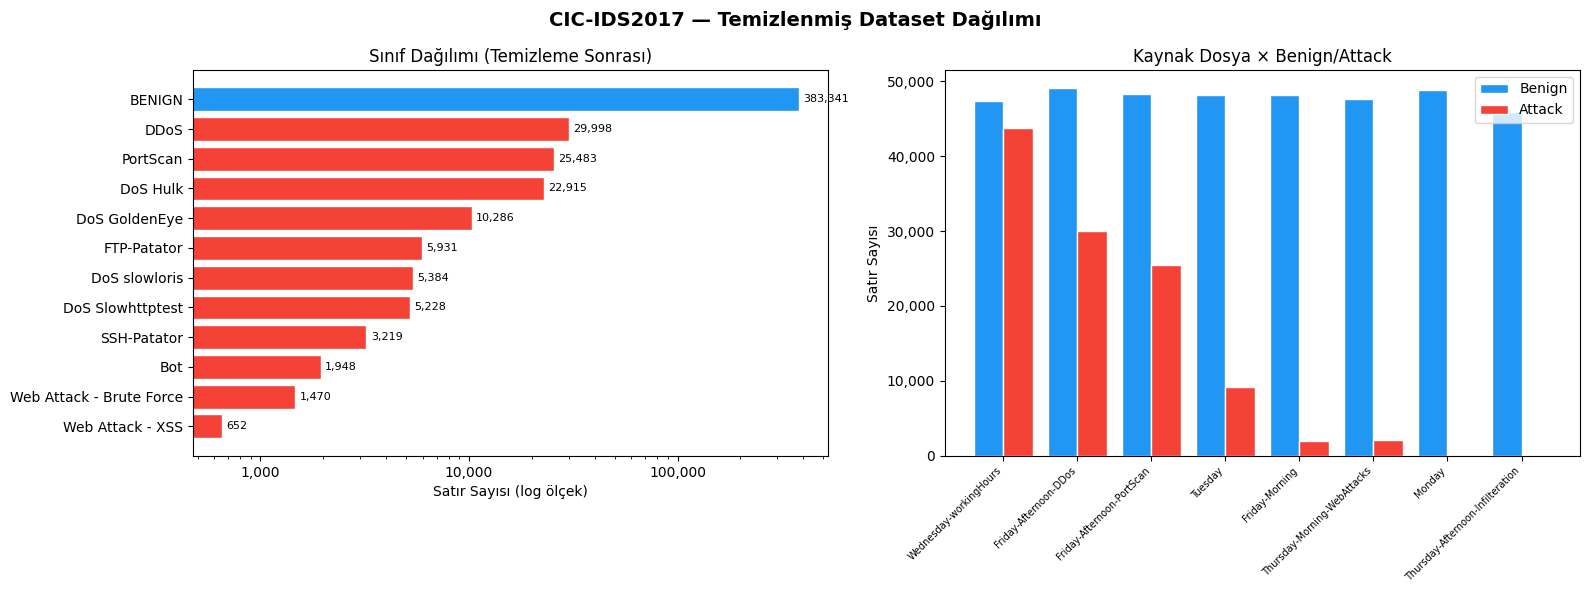

✓ Grafik kaydedildi: ../data/csv/cleaned_dataset_distribution.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("CIC-IDS2017 — Temizlenmiş Dataset Dağılımı", fontsize=14, fontweight="bold")

label_dist_clean = df["Label"].value_counts()

# ── Sol: Sınıf dağılımı (log scale) ─────────────────────────────────────────
ax = axes[0]
labels_plot = label_dist_clean.index.tolist()
counts_plot = label_dist_clean.values.tolist()
colors      = ["#2196F3" if l == "BENIGN" else "#F44336" for l in labels_plot]

bars = ax.barh(labels_plot[::-1], counts_plot[::-1], color=colors[::-1], edgecolor="white")
ax.set_xscale("log")
ax.set_xlabel("Satır Sayısı (log ölçek)")
ax.set_title("Sınıf Dağılımı (Temizleme Sonrası)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

for bar, cnt in zip(bars, counts_plot[::-1]):
    ax.text(bar.get_width() * 1.05, bar.get_y() + bar.get_height() / 2,
            f"{cnt:,}", va="center", ha="left", fontsize=8)

# ── Sağ: Kaynak dosya × Benign/Attack ────────────────────────────────────────
ax = axes[1]
if "source_file" in df.columns:
    src_dist   = df["source_file"].value_counts()
    src_benign = df[df["Label"] == "BENIGN"]["source_file"].value_counts()
    src_attack = df[df["Label"] != "BENIGN"]["source_file"].value_counts()

    src_names_short = [
        s.replace("-WorkingHours", "").replace(".pcap_ISCX.csv", "")
        for s in src_dist.index
    ]
    x = np.arange(len(src_dist))
    w = 0.4
    ax.bar(x - w/2, [src_benign.get(s, 0) for s in src_dist.index],
           w, label="Benign", color="#2196F3", edgecolor="white")
    ax.bar(x + w/2, [src_attack.get(s, 0) for s in src_dist.index],
           w, label="Attack", color="#F44336", edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(src_names_short, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("Satır Sayısı")
    ax.set_title("Kaynak Dosya × Benign/Attack")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.legend()
else:
    ax.text(0.5, 0.5, "source_file kolonu yok\n(01 notebook eski sürüm)",
            ha="center", va="center", transform=ax.transAxes, fontsize=12)
    ax.set_title("Kaynak Dosya Dağılımı — Veri Yok")

plt.tight_layout()
plt.savefig("../data/csv/cleaned_dataset_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Grafik kaydedildi: ../data/csv/cleaned_dataset_distribution.png")

## 9. Kalite Kontrol

Assert'ler sessiz hataları önler. 01 notebook'unun beklentileriyle tutarlı.

In [11]:
print("=" * 60)
print("KALİTE KONTROL")
print("=" * 60)

# 1. NaN yok
assert df.isnull().sum().sum() == 0, "HATA: Hâlâ NaN var!"
print("✓ NaN yok")

# 2. Inf yok
numeric_cols = df.select_dtypes(include=[np.number]).columns
assert not np.isinf(df[numeric_cols].values).any(), "HATA: Hâlâ Inf var!"
print("✓ Inf yok")

# 3. Rare/hatalı sınıflar yok
EXCLUDED = {"Heartbleed", "Web Attack - Sql Injection", "Infiltration"}
found_excl = df[df["Label"].isin(EXCLUDED)]["Label"].unique()
assert len(found_excl) == 0, f"HATA: Hâlâ rare/hatalı etiket var: {found_excl}"
print(f"✓ Rare/hatalı sınıflar yok")

# 4. Encoding bozukluğu yok
GARBAGE = {"Web Attack \ufffd Brute Force", "Web Attack \ufffd XSS"}
found_garb = df[df["Label"].isin(GARBAGE)]["Label"].unique()
assert len(found_garb) == 0, f"HATA: Encoding bozukluğu kaldı: {found_garb}"
print("✓ Encoding bozukluğu yok")

# 5. Benign oranı makul (%40–%90)
total     = len(df)
n_benign  = (df["Label"] == "BENIGN").sum()
benign_pct = n_benign / total * 100
assert 40 <= benign_pct <= 90, f"HATA: Benign oranı anormal → %{benign_pct:.1f}"
print(f"✓ Benign oranı makul: %{benign_pct:.1f}")

# 6. Yeterli sınıf
n_classes = df["Label"].nunique()
assert n_classes >= 5, f"HATA: Yeterli sınıf yok: {n_classes}"
print(f"✓ Sınıf sayısı: {n_classes}")

# 7. Yeterli özellik
n_features = len(df.select_dtypes(include=[np.number]).columns)
assert n_features >= 50, f"HATA: Çok az özellik kaldı: {n_features}"
print(f"✓ Numerik özellik sayısı: {n_features}")

# 8. Sıfır-varyans sütun kalmadı
zero_var_remaining = [c for c in numeric_cols if df[c].nunique() <= 1]
assert len(zero_var_remaining) == 0, f"HATA: Sıfır-varyans sütun hâlâ var: {zero_var_remaining}"
print("✓ Sıfır-varyans sütun yok")

print()
print("=" * 60)
print("ÖZET")
print("=" * 60)
print(f"  Satır        : {total:>9,}")
print(f"  Sütun        : {df.shape[1]}")
print(f"  Benign       : {n_benign:>9,}  (%{benign_pct:.1f})")
print(f"  Attack       : {total-n_benign:>9,}  (%{100-benign_pct:.1f})")
print(f"  Sınıf sayısı : {n_classes}")
print()
print("=" * 60)
print("DATASET HAZIR → sonraki adım: 03_feature_engineering.ipynb")
print("=" * 60)

KALİTE KONTROL
✓ NaN yok
✓ Inf yok
✓ Rare/hatalı sınıflar yok
✓ Encoding bozukluğu yok
✓ Benign oranı makul: %77.3
✓ Sınıf sayısı: 12
✓ Numerik özellik sayısı: 70
✓ Sıfır-varyans sütun yok

ÖZET
  Satır        :   495,855
  Sütun        : 72
  Benign       :   383,341  (%77.3)
  Attack       :   112,514  (%22.7)
  Sınıf sayısı : 12

DATASET HAZIR → sonraki adım: 03_feature_engineering.ipynb


## 10. Kaydetme

In [12]:
df.to_csv(OUTPUT_PATH, index=False)

size_mb = os.path.getsize(OUTPUT_PATH) / (1024 * 1024)
print(f"✓ Temizlenmiş dataset kaydedildi: {OUTPUT_PATH}")
print(f"  Boyut  : {size_mb:.1f} MB")
print(f"  Satır  : {len(df):,}")
print(f"  Sütun  : {df.shape[1]}")

✓ Temizlenmiş dataset kaydedildi: ../data/csv/cleaned_dataset.csv
  Boyut  : 177.4 MB
  Satır  : 495,855
  Sütun  : 72
